In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle, h5py, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM

from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters

23-07-05 08:10:45    scales.py INF   Setting up healpy to run on 256 CPUs 


In [3]:
params = ["Om", "s8", "Aia"]
base_dir = "/global/cfs/cdirs/des/vajani/combined-probes/output/Weak_Lensing/grid/Power_Spectra/dictionaries"
label = f"virginia_cls"

### load the grid from Virginia's dicts

### auto + cross

In [4]:
n_params = 3
n_examples = 16
n_summary = 32

# Om, s8, Aia
grid_theta = []
grid_cls = []

for i in range(4):
    for j in range(4):
        if i <= j:
            bin_num = f"{i+1}x{j+1}"
            print(f"Loading bin_num = {bin_num}")
            
            with open(os.path.join(base_dir, f'bin{bin_num}/power_spec_dict_bin{bin_num}.pickle'), 'rb') as f:
                current_dict = pickle.load(f)
            
            current_cls = np.zeros((len(current_dict), n_examples, n_summary))

            # loop through the dictionary
            for k, (key, value) in enumerate(current_dict.items()):
    
                # extract the cosmological parameters
                current_theta_list = key.replace("[", "").replace("]", "").strip().split(" ")
                current_theta_list = list(filter(None, current_theta_list))
                current_theta_list = [float(item) for item in current_theta_list] 

                # only save the cosmological parameters once
                if i == 0 and j == 0:
                    grid_theta.append(np.array(current_theta_list))
                    
                # check otherwise
                else:
                    assert np.all(grid_theta[k] == current_theta_list)
                    
                current_cls[k] = np.stack(value, axis=0)
                
            grid_cls.append(current_cls)

# # collect the different cosmologies
grid_theta = np.stack(grid_theta, axis=0)
grid_cls = np.concatenate(grid_cls, axis=-1)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

# remove the example axis
grid_cls = np.concatenate(grid_cls, axis=0)
grid_theta = np.repeat(grid_theta, grid_cls.shape[0]//grid_theta.shape[0], axis=0)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

Loading bin_num = 1x1
Loading bin_num = 1x2
Loading bin_num = 1x3
Loading bin_num = 1x4
Loading bin_num = 2x2
Loading bin_num = 2x3
Loading bin_num = 2x4
Loading bin_num = 3x3
Loading bin_num = 3x4
Loading bin_num = 4x4

grid_theta.shape = (2499, 3)
grid_cls.shape = (2499, 16, 320)

grid_theta.shape = (39984, 3)
grid_cls.shape = (39984, 320)


### auto only

In [45]:
n_params = 3
n_examples = 16
n_summary = 32

# Om, s8, Aia
grid_theta = []
grid_cls = []

for i in range(4):
    bin_num = f"{i+1}x{i+1}"
    print(f"Loading bin_num = {bin_num}")

    with open(os.path.join(base_dir, f'bin{bin_num}/power_spec_dict_bin{bin_num}.pickle'), 'rb') as f:
        current_dict = pickle.load(f)

    current_cls = np.zeros((len(current_dict), n_examples, n_summary))

    # loop through the dictionary
    for k, (key, value) in enumerate(current_dict.items()):

        # extract the cosmological parameters
        current_theta_list = key.replace("[", "").replace("]", "").strip().split(" ")
        current_theta_list = list(filter(None, current_theta_list))
        current_theta_list = [float(item) for item in current_theta_list] 

        # only save the cosmological parameters once
        if i == 0:
            grid_theta.append(np.array(current_theta_list))

        # check otherwise
        else:
            assert np.all(grid_theta[k] == current_theta_list)
            
        
            
            
        current_cls[k] = np.stack(value, axis=0)

    grid_cls.append(current_cls)

# # collect the different cosmologies
grid_theta = np.stack(grid_theta, axis=0)
grid_cls = np.concatenate(grid_cls, axis=-1)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

# remove the example axis
grid_cls = np.concatenate(grid_cls, axis=0)
grid_theta = np.repeat(grid_theta, grid_cls.shape[0]//grid_theta.shape[0], axis=0)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

Loading bin_num = 1x1
Loading bin_num = 2x2
Loading bin_num = 3x3
Loading bin_num = 4x4

grid_theta.shape = (2499, 3)
grid_cls.shape = (2499, 16, 128)

grid_theta.shape = (39984, 3)
grid_cls.shape = (39984, 128)


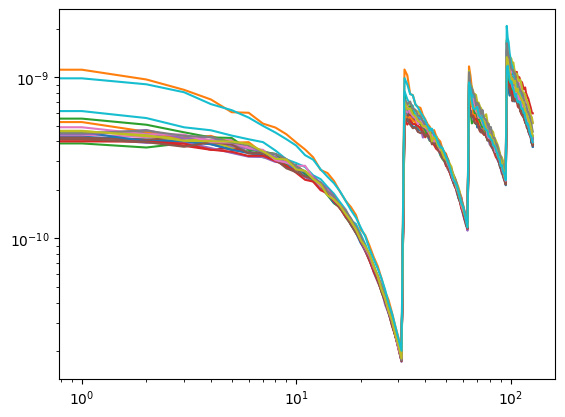

In [66]:
random_indices = np.random.choice(np.arange(grid_cls.shape[0]), 20)

fig, ax = plt.subplots()

for i in random_indices:    
    ax.plot(grid_cls[i])
    ax.set(xscale="log", yscale="log")
    

### compress with PCA

In [57]:
pca = PCA(n_components=1)

print(grid_cls.shape)
grid_compressed_cls = pca.fit_transform(grid_cls)
print(grid_compressed_cls.shape)

(39984, 128)
(39984, 1)


In [60]:
pca = PCA(n_components=1)

print(grid_cls.shape)
grid_compressed_cls = pca.fit_transform(grid_cls)
print(grid_compressed_cls.shape)

print(grid_cls - pca.inverse_transform(grid_compressed_cls))

(39984, 128)
(39984, 1)
[[-1.78778714e-11 -4.32841862e-11 -6.43569433e-12 ... -2.46549469e-11
  -2.01206023e-11 -5.66077762e-12]
 [ 4.43612400e-12 -6.31851233e-11 -1.94015929e-11 ... -2.67901060e-11
  -1.29534007e-11 -1.05823853e-11]
 [-5.56167345e-11 -8.90140908e-12 -1.85791207e-11 ... -2.55056672e-11
  -1.67583870e-11 -2.13271775e-11]
 ...
 [ 6.39841885e-12  2.14789666e-11  4.38044895e-12 ...  1.19632284e-11
   9.58396940e-12  9.69755714e-12]
 [ 4.68130040e-12  1.40443532e-11  3.08407412e-12 ...  6.39182654e-12
  -6.25926221e-13  3.60544280e-12]
 [-7.38035865e-12 -1.44880673e-11  9.85916734e-12 ... -6.87106817e-12
  -1.92265225e-11 -1.31935669e-12]]


In [61]:
pca = PCA(n_components=10)

print(grid_cls.shape)
grid_compressed_cls = pca.fit_transform(grid_cls)
print(grid_compressed_cls.shape)

print(grid_cls - pca.inverse_transform(grid_compressed_cls))

(39984, 128)
(39984, 10)
[[ 2.36244823e-11 -1.62624977e-11  1.63799172e-11 ... -4.63647061e-12
  -3.55114620e-13  1.36525154e-11]
 [ 4.24812672e-11 -3.62396034e-11  6.26251651e-13 ... -9.14019312e-12
   4.34629472e-12  6.14325368e-12]
 [-1.64526499e-11  1.55087954e-11  6.96960898e-13 ... -1.43813075e-11
  -5.89695991e-12 -1.06223455e-11]
 ...
 [ 2.37431097e-12  1.55579552e-11  9.26448151e-13 ... -6.06771754e-12
  -7.83256768e-12 -6.87793487e-12]
 [-1.22520070e-11  5.43743068e-12 -2.83780422e-12 ... -5.44570344e-12
  -1.22006038e-11 -7.61544516e-12]
 [-4.62875637e-12 -1.38594132e-11  1.15952129e-11 ... -9.39507760e-12
  -2.16171392e-11 -3.52014421e-12]]


In [58]:
squared_diff = (grid_cls - pca.inverse_transform(grid_compressed_cls))**2

print(squared_diff.max())

2.923562079560369e-18


(array([1.12399901e+20, 1.65709616e+16, 1.44095318e+15, 5.27177992e+14,
        5.09605393e+14, 4.92032793e+14, 7.02903990e+13, 0.00000000e+00,
        7.02903990e+13, 7.02903990e+13]),
 array([1.14280297e-37, 8.89524187e-21, 1.77904837e-20, 2.66857256e-20,
        3.55809675e-20, 4.44762093e-20, 5.33714512e-20, 6.22666931e-20,
        7.11619350e-20, 8.00571768e-20, 8.89524187e-20]),
 <BarContainer object of 10 artists>)

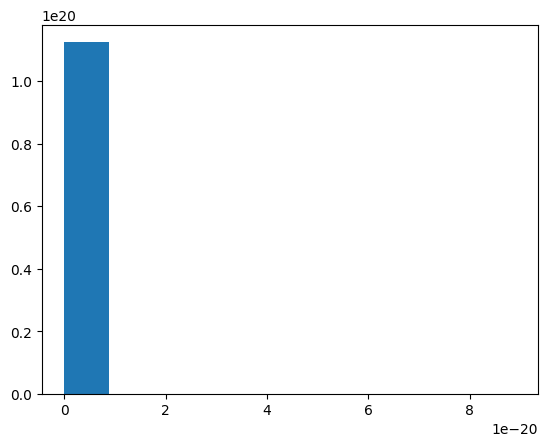

In [37]:
squared_diff = (grid_cls - pca.inverse_transform(grid_compressed_cls))**2

fig, ax = plt.subplots()

ax.hist(squared_diff.ravel(), density=True)

In [38]:
squared_diff

array([[1.01479861e-21, 1.85419902e-22, 3.50432683e-22, ...,
        8.06103762e-24, 1.69162631e-24, 2.37875317e-22],
       [1.23871173e-21, 1.79765161e-21, 1.91312409e-23, ...,
        8.06003491e-23, 2.06951310e-23, 4.06211251e-23],
       [6.25191739e-22, 8.41731065e-23, 5.85742459e-24, ...,
        1.94018197e-22, 3.00523796e-23, 1.02786386e-22],
       ...,
       [4.51010772e-25, 1.08547907e-22, 2.53220469e-24, ...,
        2.50625697e-23, 4.12563428e-23, 3.18078579e-23],
       [8.63235312e-24, 1.48009249e-22, 1.50937596e-24, ...,
        1.30116109e-23, 1.02397403e-22, 3.40953860e-23],
       [1.84941854e-22, 4.52269954e-22, 5.47825455e-23, ...,
        1.12943608e-22, 5.14266515e-22, 2.13800117e-23]])

(array([1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 1.0000000e+00, 4.0000000e+00, 3.9000000e+01,
        1.2792273e+07, 2.0000000e+00]),
 array([-1147041.97567397, -1005247.1311016 ,  -863452.28652923,
         -721657.44195686,  -579862.59738449,  -438067.75281212,
         -296272.90823975,  -154478.06366738,   -12683.21909502,
          129111.62547735,   270906.47004972]),
 <BarContainer object of 10 artists>)

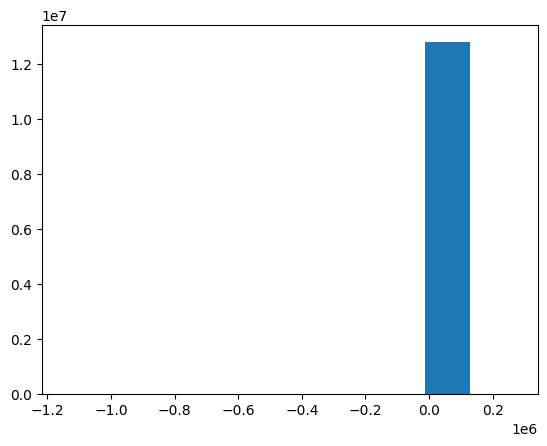

In [35]:
residual = grid_cls - pca.inverse_transform(grid_compressed_cls)
relative_error = residual/grid_cls

relative_error = relative_error.ravel()
relative_error = relative_error[np.isfinite(relative_error)]

plt.hist(relative_error, density=True)

### load the observation

In [48]:
obs_cls = grid_cls[7]
print(grid_theta[7])

obs_compressed_cls = pca.transform(np.atleast_2d(obs_cls))

[0.3 0.9 0. ]


### inference with mixture of Gaussians

In [49]:
# p(y | x) <=> p(cls | theta)
model = ConditionalGMM(
    # theta
    x_dim=grid_theta.shape[1],
    # cls
    y_dim=grid_compressed_cls.shape[1],
    out_dir=None,
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

23-07-05 08:28:48 gaussian_mix INF   Created GMM model with n_params = 266248 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise_1 (GaussianN  (None, 3)                0         
 oise)                                                           
                                                                 
 dense_5 (Dense)             (None, 256)               1024      
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_6 (Dense)             (None, 256)               65792     
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (N

In [50]:
fit_history = model.fit(
    x=grid_theta,
    y=grid_compressed_cls,
    epochs=500,
    batch_size=2499,
    early_stopping_callback=True,
    learning_rate_callback=False,
)

23-07-05 08:28:50 gaussian_mix INF   Fitted the x and y scalers 


epoch:  52%|█████▏    | 259/500 [00:27<00:24,  9.98it/s, loss=-9.78, val_loss=-9.31, lr=None]

Restoring model weights from the end of the best epoch: 160.


epoch:  52%|█████▏    | 260/500 [00:27<00:24, 10.00it/s, loss=-9.91, val_loss=-8.93, lr=None]

Epoch 260: early stopping


epoch:  52%|█████▏    | 260/500 [00:27<00:25,  9.34it/s, loss=-9.91, val_loss=-8.93, lr=None]

23-07-05 08:29:18 gaussian_mix INF   Finished training 


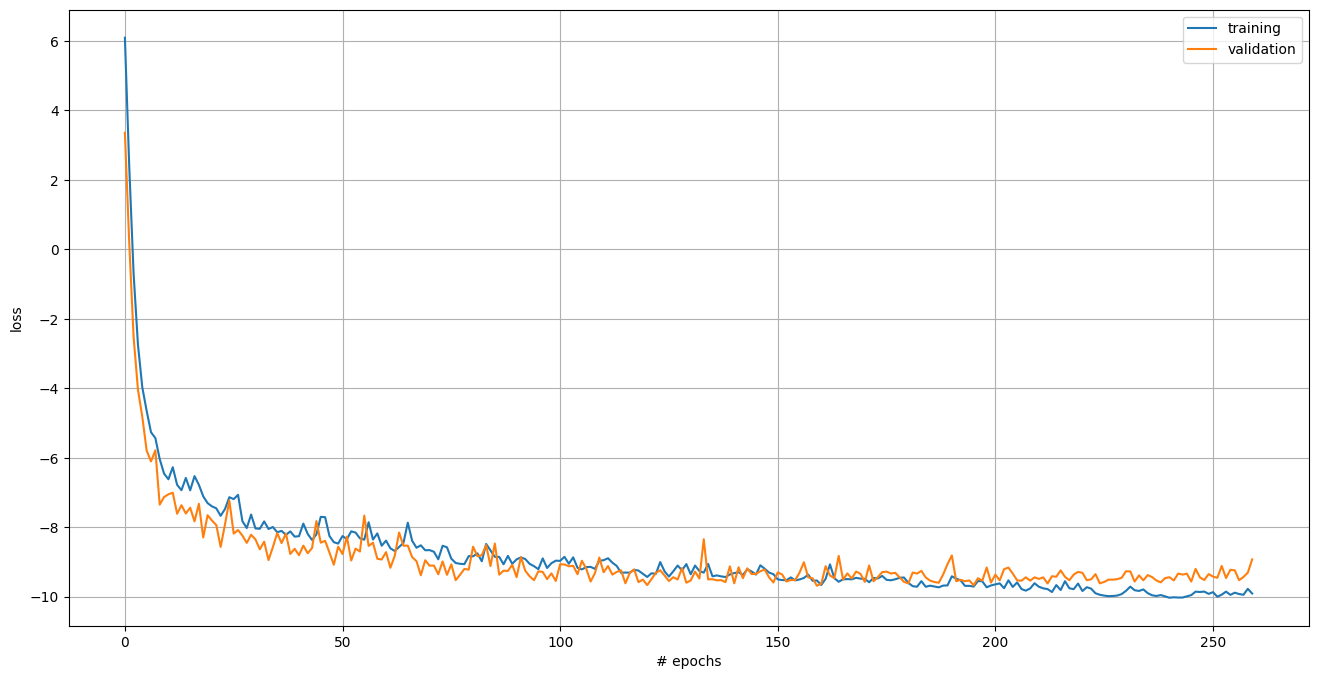

In [51]:
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

## MCMC

In [52]:
tf_pred = tf.cast(obs_compressed_cls, dtype=tf.float32)

def log_likelihood(X): 
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

In [54]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=None,
    label=label,
    n_steps=500,
)

23-07-05 08:30:45      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [01:08<00:00,  7.30it/s]

23-07-05 08:32:08      mcmc.py WAR   Not saving the chain 


## plot

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

23-07-05 08:32:36  plotting.py WAR   Not saving the plot 


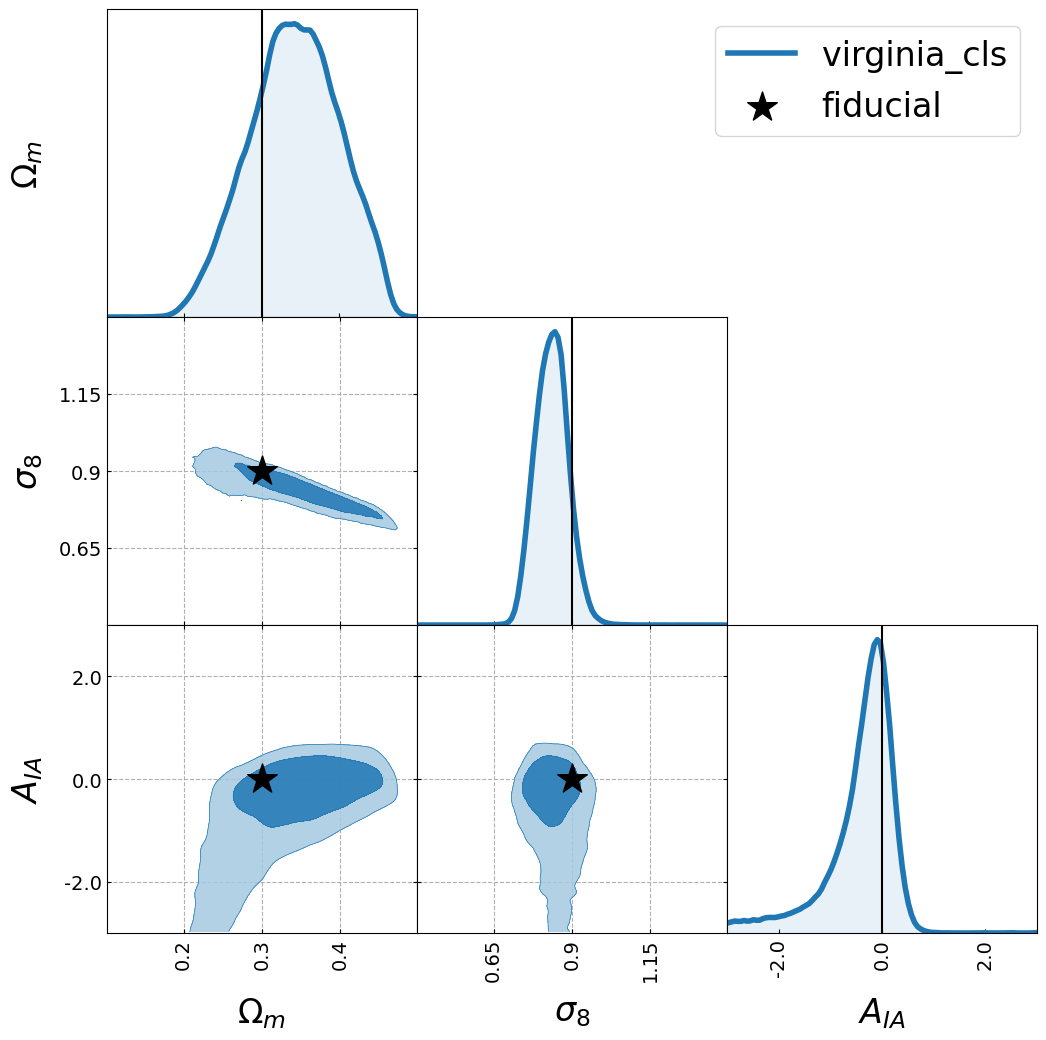

In [55]:
plotting.plot_chain(
    chain, 
    params, 
    out_dir=None, 
    label=label,
)